In [2]:
'''
Make examples of 2D systematics we might expect to see in IR detectors

Created 2026 May 5
'''

'\nMake examples of 2D systematics we might expect to see in IR detectors\n\nCreated 2026 May 5\n'

In [3]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


In [4]:
H, W = 1024, 1024
canvas = np.zeros((H,W))

In [5]:
dict_systematics = {}

## Hot pixels [units counts]

In [6]:
H, W = 1024, 1024
canvas_badpix = np.random.rand(H, W)
frac_bad = 0.1
idx_hot = canvas_badpix > 1-frac_bad
idx_norm = canvas_badpix <= 1-frac_bad
canvas_badpix[idx_hot] = 1000
canvas_badpix[idx_norm] = 0
dict_systematics['hot_pixels'] = canvas_badpix


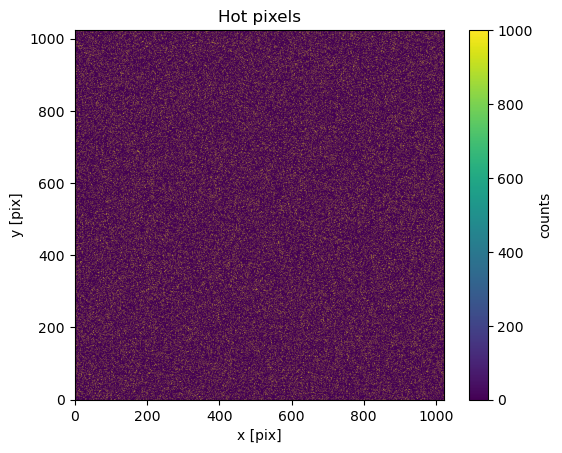

In [7]:
fig, ax = plt.subplots(1,1)
#ax.imshow(dict_systematics['hot_pixels'])
ax.imshow(canvas_badpix, origin='lower')
ax.set_title('Hot pixels')
ax.set_xlabel('x [pix]')
ax.set_ylabel('y [pix]')
fig.colorbar(ax.images[0], ax=ax, label='counts')
#plt.show()
plt.savefig('hot_pixels.png')

# Save hot pixels pattern to a FITS file
hdu = fits.PrimaryHDU(canvas_badpix.astype(np.float32))
hdu.writeto('systematics_hot_pixels.fits', overwrite=True)



## Dark current (gradient) [e pix-1 sec-1]

In [8]:
H, W = 1024, 1024
canvas_dc_grad = np.random.rand(H, W)

N_max = 3.0
N_min = 1.0
# Grid of pixel coordinates
y, x = np.indices((H, W))
# Distance from one corner (0, 0)
r = np.sqrt(x**2 + y**2)
# Normalize by farthest distance in the image
r_max = np.sqrt((W - 1)**2 + (H - 1)**2)
t = np.clip(r / r_max, 0, 1)
# Circular gradient: max at corner, min at farthest point
canvas_dc_grad = N_max - (N_max - N_min) * t

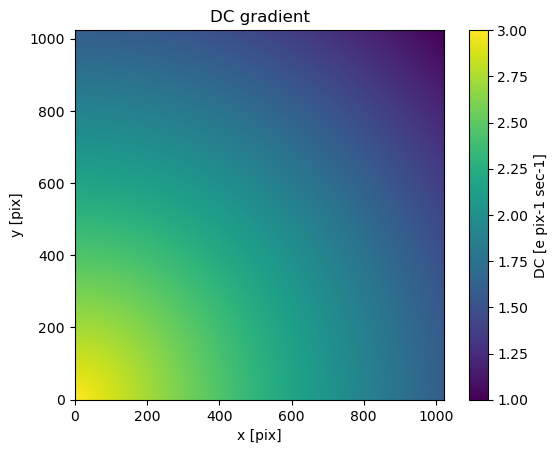

In [9]:
fig, ax = plt.subplots(1,1)
#ax.imshow(dict_systematics['hot_pixels'])
ax.imshow(canvas_dc_grad, origin='lower')
ax.set_title('DC gradient')
ax.set_xlabel('x [pix]')
ax.set_ylabel('y [pix]')
fig.colorbar(ax.images[0], ax=ax, label='DC [e pix-1 sec-1]')
#plt.show()
plt.savefig('dc_gradient.png')

# Save to FITS
hdu = fits.PrimaryHDU(canvas_dc_grad.astype(np.float32))
hdu.writeto('systematics_dc_gradient.fits', overwrite=True)

## Read noise pattern [counts]



In [10]:
H, W = 1024, 1024
period = 18.0          # lattice spacing (pixels)
angle_deg = 28.0       # crystal orientation
blur_sigma = 2.2       # blur amount
irregularity = 0.08    # slight crystalline disorder
contrast = 0.35        # hatch contrast
read_offset = 0.1       # min read noise value
# Coordinate grid
y, x = np.indices((H, W))
x = x.astype(float)
y = y.astype(float)
# Rotate axes to represent crystal lattice directions
theta = np.deg2rad(angle_deg)
u =  np.cos(theta) * x + np.sin(theta) * y
v = -np.sin(theta) * x + np.cos(theta) * y
# Add gentle low-frequency distortion (imperfect crystal domains)
rng = np.random.default_rng(7)
du = gaussian_filter(rng.normal(size=(H, W)), sigma=25) * period * irregularity
dv = gaussian_filter(rng.normal(size=(H, W)), sigma=25) * period * irregularity
u2, v2 = u + du, v + dv
# Cross-hatching from two near-orthogonal lattice families
h1 = np.cos(2 * np.pi * u2 / period)
h2 = np.cos(2 * np.pi * v2 / period)
# Optional weak secondary family for crystalline feel
h3 = np.cos(2 * np.pi * (0.6*u2 + 0.8*v2) / (period * 1.5))
pattern = 0.5 + contrast * (0.45*h1 + 0.45*h2 + 0.10*h3)
# Blur to make it "blurry" and detector-like
pattern = gaussian_filter(pattern, sigma=blur_sigma)
# Normalize to [0, 1]
canvas_read_pattern = read_offset + (pattern - pattern.min()) / (pattern.max() - pattern.min() + 1e-12)

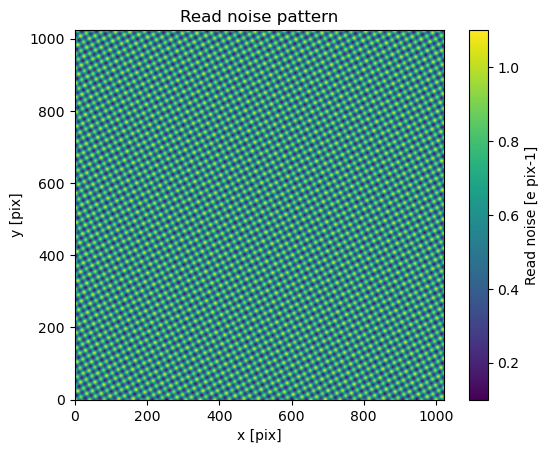

In [11]:
fig, ax = plt.subplots(1,1)
#ax.imshow(dict_systematics['hot_pixels'])
ax.imshow(canvas_read_pattern, origin='lower')
ax.set_title('Read noise pattern')
ax.set_xlabel('x [pix]')
ax.set_ylabel('y [pix]')
fig.colorbar(ax.images[0], ax=ax, label='Read noise [e pix-1]')
#plt.show()
plt.savefig('read_noise_pattern.png')

# Save to FITS
hdu = fits.PrimaryHDU(canvas_read_pattern.astype(np.float32))
hdu.writeto('systematics_read_pattern.fits', overwrite=True)


## Cosmic rays [counts]

In [12]:
def add_cosmic_rays(image, num_rays=50, max_flux=5000):
    """
    Adds simple cosmic ray hits to a numpy array.
    """
    ny, nx = image.shape
    for _ in range(num_rays):
        # Random position
        x, y = np.random.randint(0, nx), np.random.randint(0, ny)
        
        # Add a bright spot (1x1 or small 3x3)
        length = np.random.randint(10, 30)
        width = np.random.randint(1, 3)
        angle_deg = np.random.randint(0, 360)

        # Generate a shape defined by the above 3 parameters.
        # Calculate the endpoints of the cosmic ray track
        theta = np.deg2rad(angle_deg)
        dx = np.cos(theta)
        dy = np.sin(theta)
        
        # Determine start and end points
        x0 = x - int((length / 2) * dx)
        y0 = y - int((length / 2) * dy)
        x1 = x + int((length / 2) * dx)
        y1 = y + int((length / 2) * dy)
        
        # Create a linear path between start and end points
        for l in np.linspace(0, 1, length):
            cx = int(x0 + (x1 - x0) * l)
            cy = int(y0 + (y1 - y0) * l)
            for wx in range(-width, width+1):
                for wy in range(-width, width+1):
                    ix = cx + wx
                    iy = cy + wy
                    if 0 <= ix < nx and 0 <= iy < ny:
                        image[iy, ix] += max_flux * np.random.uniform(0.5, 1.0)
        
                
    return image


In [13]:
H, W = 1024, 1024
canvas_cosmic_rays = np.zeros((H, W))
N_hits = 500

test = add_cosmic_rays(canvas_cosmic_rays, num_rays=N_hits)

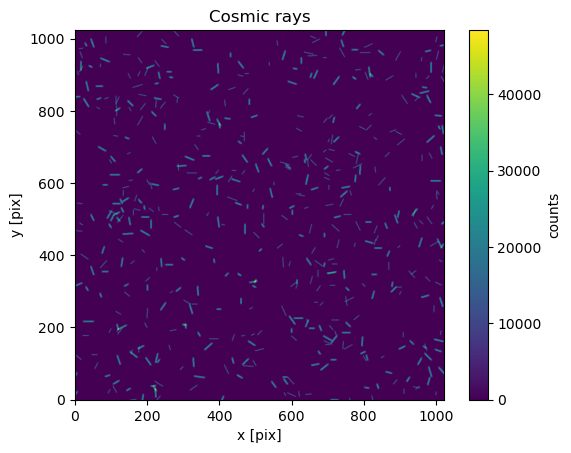

In [14]:
fig, ax = plt.subplots(1,1)
ax.imshow(test, origin='lower')
ax.set_title('Cosmic rays')
ax.set_xlabel('x [pix]')
ax.set_ylabel('y [pix]')
fig.colorbar(ax.images[0], ax=ax, label='counts')
#plt.show()
plt.savefig('cosmic_rays.png')

# Save to FITS
hdu = fits.PrimaryHDU(canvas_cosmic_rays.astype(np.float32))
hdu.writeto('systematics_cosmic_rays.fits', overwrite=True)


## Persistence (one frame only) [counts]

## Odd versus even detector row signal difference [counts]

## Gain variations [unitless]

In [15]:
# Dark current (gradient)